# Netflix Exploratory Data Analysis

### Data Cleaning

Importing required libraries.

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading the data into the dataframe.

In [106]:
df = pd.read_csv("netflix_titles.csv")

In [107]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Checking data types and changing it if necessary.

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [109]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

Checking for duplicates.

In [110]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)
# no duplicates, yay!

number of duplicate rows:  (0, 12)


Rearranging data and renaming columns.

In [111]:
df = df.rename(columns={'show_id': 'title_id', 'listed_in': 'genres'})
df.head()

,title_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [112]:
# Extract minutes
df['minutes'] = df['duration'].str.extract(r'(\d+)\s*min', expand=False)
df['minutes'] = df['minutes'].fillna(0).astype(int)

# Extract seasons
df['seasons'] = df['duration'].str.extract(r'(\d+)\s*Season', expand=False)
df['seasons'] = df['seasons'].fillna(0).astype(int)

# delete duration column
df = df.drop(columns=['duration'])

df.head()

,title_id,type,title,director,cast,country,date_added,release_year,rating,genres,description,minutes,seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90,0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",0,2
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,0,1
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",0,1
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,0,2


Handling null values.

In [113]:
print('total rows: ' + str(len(df)))

total rows: 8807


In [114]:
df.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        98
rating             4
title_id           0
type               0
title              0
release_year       0
genres             0
description        0
minutes            0
seasons            0
dtype: int64

In [115]:
# Handling nulls in director column
df['director'] = df['director'].fillna('Missing Director')

# Handling unknown countries
df['country'] = df['country'].fillna('Unknown')

df.head()

,title_id,type,title,director,cast,country,date_added,release_year,rating,genres,description,minutes,seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90,0
1,s2,TV Show,Blood & Water,Missing Director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",0,2
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,0,1
3,s4,TV Show,Jailbirds New Orleans,Missing Director,NaN,Unknown,2021-09-24,2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",0,1
4,s5,TV Show,Kota Factory,Missing Director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,0,2


### Data Analysis

Extract unique genres for each title.

In [116]:
genres = df[["title_id", "genres"]].copy()

genres.head()

,title_id,genres
0,s1,Documentaries
1,s2,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,"Docuseries, Reality TV"
4,s5,"International TV Shows, Romantic TV Shows, TV ..."


In [117]:
genres["genres"] = genres["genres"].str.split(",")
genres = genres.explode("genres")

genres.head()

,title_id,genres
0,s1,Documentaries
1,s2,International TV Shows
1,s2,TV Dramas
1,s2,TV Mysteries
2,s3,Crime TV Shows


In [118]:
# used for top genres bar chart
top_genres = (genres
    .groupby("genres")["title_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

Extract unique countries for each title.

In [119]:
countries = df[["title_id", "country"]].copy()

countries.head()

,title_id,country
0,s1,United States
1,s2,South Africa
2,s3,Unknown
3,s4,Unknown
4,s5,India


In [120]:
countries["country"] = countries["country"].str.split(",")
countries = countries.explode("country")
countries["country"] = countries["country"].str.strip()

countries.head()

,title_id,country
0,s1,United States
1,s2,South Africa
2,s3,Unknown
3,s4,Unknown
4,s5,India


Get titles associated with each country.

In [121]:
top_titles_per_country = (
    countries
    .loc[countries["country"].ne("Unknown")]   # remove Unknown from list of top 15
    .groupby("country")["title_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

top_titles_per_country

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          160
Egypt              117
Turkey             113
Hong Kong          105
Name: title_id, dtype: int64

Extract actors from cast lists.

In [122]:
actors = df[["title_id", "cast"]].copy()
actors = actors.rename(columns={'cast': 'actor'})

actors.head()

,title_id,actor
0,s1,NaN
1,s2,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban..."
2,s3,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi..."
3,s4,NaN
4,s5,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K..."


In [123]:
actors["actor"] = actors["actor"].str.split(",")
actors = actors.explode("actor")
actors["actor"] = actors["actor"].str.strip()

actors.head()

,title_id,actor
0,s1,NaN
1,s2,Ama Qamata
1,s2,Khosi Ngema
1,s2,Gail Mabalane
1,s2,Thabang Molaba


In [124]:
titles_per_actor = (
    actors
    .groupby("actor")["title_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

titles_per_actor

actor
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Takahiro Sakurai    32
Naseeruddin Shah    32
Rupa Bhimani        31
Om Puri             30
Akshay Kumar        30
Yuki Kaji           29
Amitabh Bachchan    28
Name: title_id, dtype: int64

Content added over the years

In [125]:
df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year
df['year_added']

0       2021.0
1       2021.0
2       2021.0
3       2021.0
4       2021.0
         ...  
8802    2019.0
8803    2019.0
8804    2019.0
8805    2020.0
8806    2019.0
Name: year_added, Length: 8807, dtype: float64

In [137]:
count_per_yr = df.groupby(['year_added', 'type']).size()
count_per_yr

year_added  type   
2008.0      Movie         1
            TV Show       1
2009.0      Movie         2
2010.0      Movie         1
2011.0      Movie        13
2012.0      Movie         3
2013.0      Movie         6
            TV Show       4
2014.0      Movie        19
            TV Show       4
2015.0      Movie        56
            TV Show      17
2016.0      Movie       253
            TV Show     165
2017.0      Movie       839
            TV Show     325
2018.0      Movie      1237
            TV Show     388
2019.0      Movie      1424
            TV Show     575
2020.0      Movie      1284
            TV Show     594
2021.0      Movie       993
            TV Show     505
dtype: int64

In [138]:
count_per_yr = count_per_yr.reset_index(name='count')
count_per_yr

,year_added,type,count
0,2008.0,Movie,1
1,2008.0,TV Show,1
2,2009.0,Movie,2
3,2010.0,Movie,1
4,2011.0,Movie,13
5,2012.0,Movie,3
6,2013.0,Movie,6
7,2013.0,TV Show,4
8,2014.0,Movie,19
9,2014.0,TV Show,4


### Visualizations

**Propotion of Movies vs TV Shows on Netflix**  
The following pie chart shows the proportions of movies versus shows, demonstrating the available content types.

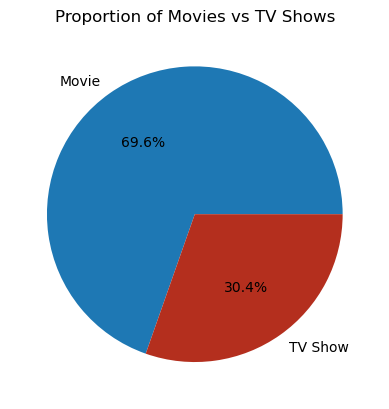

In [139]:
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#1e78b4','#b42f1e'])
plt.title('Proportion of Movies vs TV Shows')
plt.ylabel('')
plt.show()

**Top 15 Genres on Netflix**  
This chart highlights the most popular genres among Netlix users, providing insight into the types of content that dominate the platform.

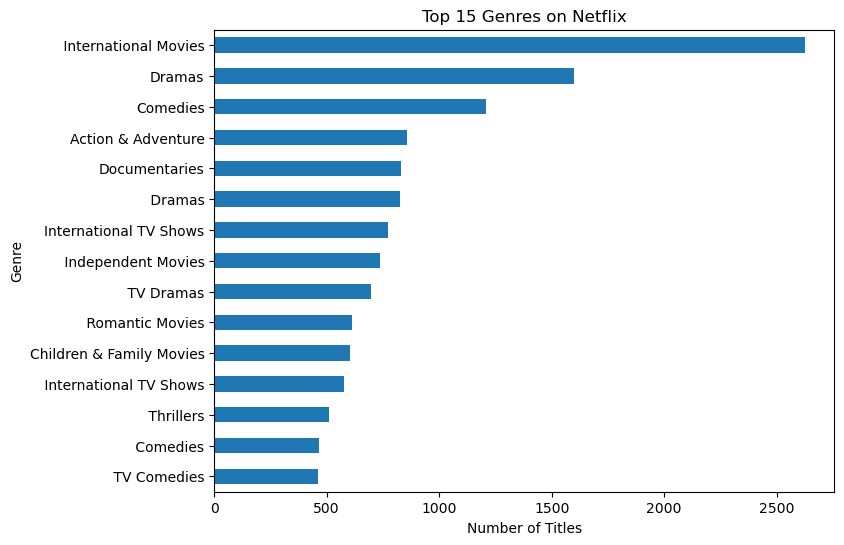

In [140]:
# Set up bar chart for the top 15 genres on Netflix
plt.figure(figsize = (8,6))
top_genres.plot(kind="barh", title="Top 15 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

# Used to have chart in descending order
plt.gca().invert_yaxis()
plt.show()

**Number of Netflix Titles by Top 15 Countries**  
This chart shows the top 15 countries with the most titles available, highlighting the countries that lead inproduction.

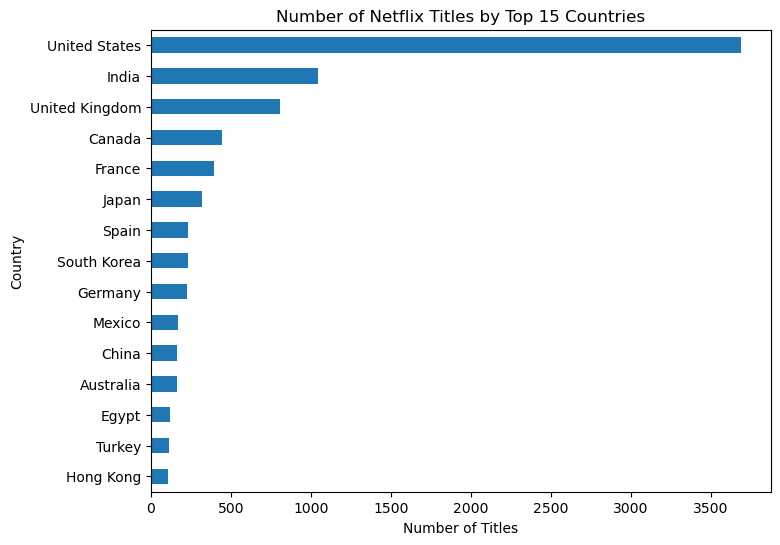

In [141]:
plt.figure(figsize = (8,6))
top_titles_per_country.plot(kind="barh", title="Number of Netflix Titles by Top 15 Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.gca().invert_yaxis()
plt.show()

**Top 10 Most Featured Actors on Netflix**  
This chart shows the actors who appear in the greatest number of unique Netflix titles, based on the available cast data.

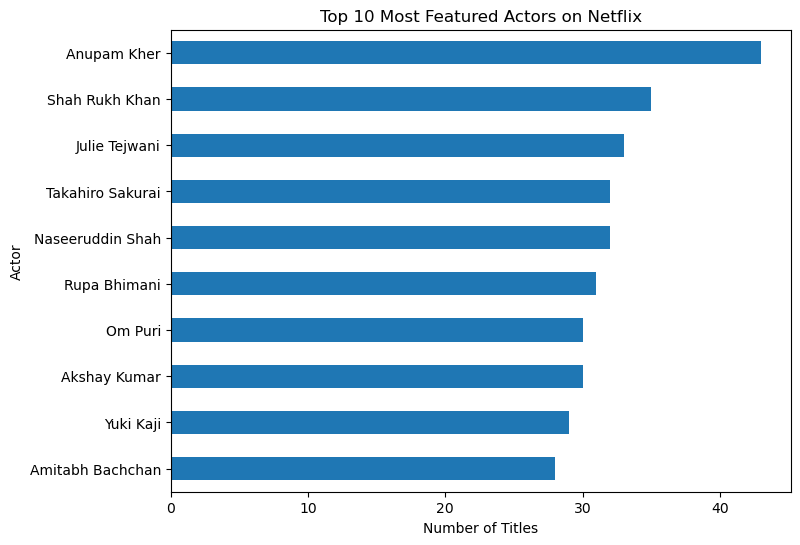

In [142]:
plt.figure(figsize = (8,6))
titles_per_actor.plot(kind="barh", title="Top 10 Most Featured Actors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Actor")

plt.gca().invert_yaxis()
plt.show()

**Movies and TV Shows Added Over the Years**  
This graph shows the number of movies and shows added to Netflix each year, underscoring trends in content type release and the years with the most production.

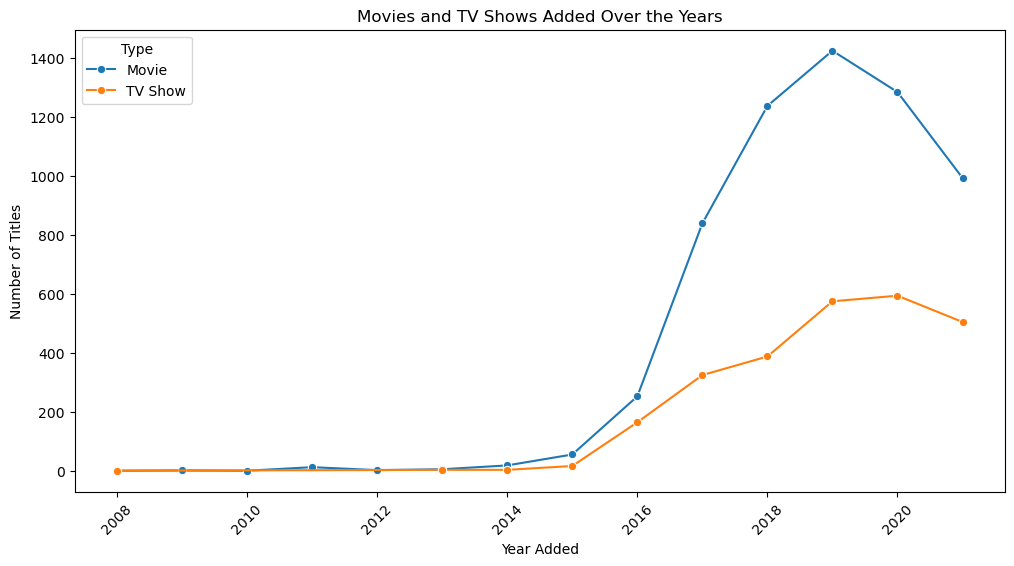

In [149]:
plt.figure(figsize=(12,6))
sns.lineplot(data=count_per_yr, x='year_added', y='count', hue='type', marker='o')
plt.title('Movies and TV Shows Added Over the Years')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Type')

plt.show()